W shape: (108, 9375)


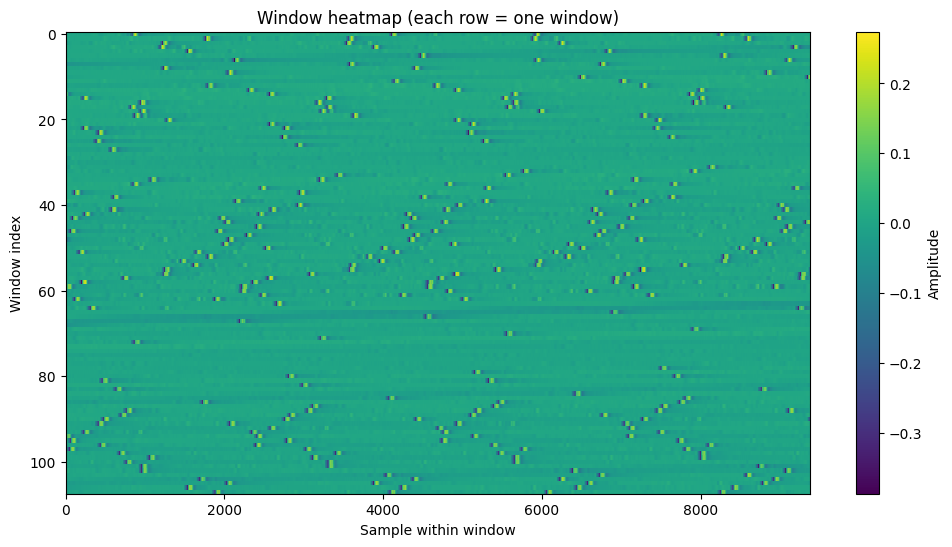

In [2]:
import numpy as np
import matplotlib.pyplot as plt

npz_path = "../../data/emglab/windows_w400_h100/N2001A01AP52.npz"  # change this

d = np.load(npz_path)
W = d["windows"]  # (n_windows, win_samples)

print("W shape:", W.shape)

plt.figure(figsize=(12, 6))
plt.imshow(W, aspect="auto", interpolation="nearest")
plt.title("Window heatmap (each row = one window)")
plt.xlabel("Sample within window")
plt.ylabel("Window index")
plt.colorbar(label="Amplitude")
plt.show()

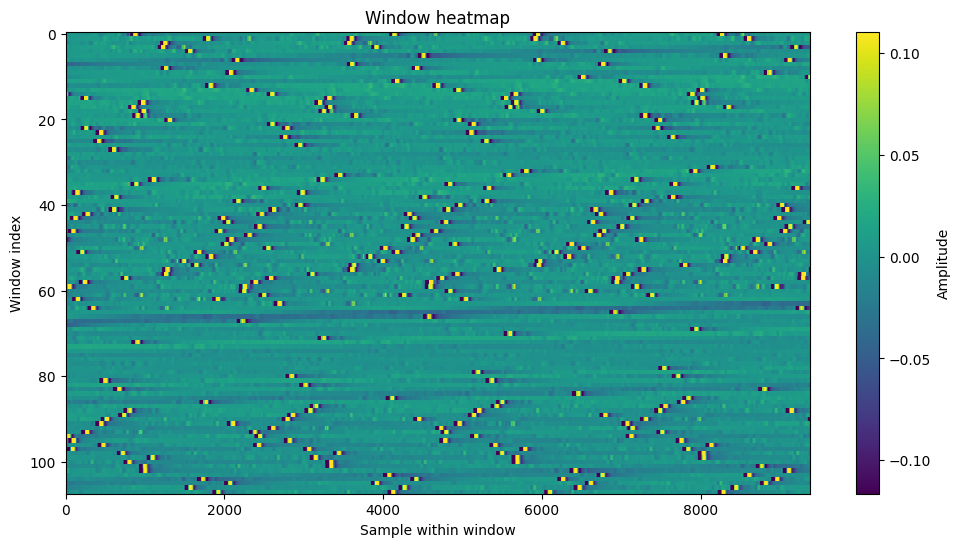

Robust vmin/vmax: -0.11645568847656251 0.110443115234375


In [2]:
d = np.load(npz_path)
W = d["windows"]

vmin, vmax = np.percentile(W, [1, 99])  # robust limits

plt.figure(figsize=(12, 6))
plt.imshow(W, aspect="auto", interpolation="nearest", vmin=vmin, vmax=vmax)
plt.title("Window heatmap")
plt.xlabel("Sample within window")
plt.ylabel("Window index")
plt.colorbar(label="Amplitude")
plt.show()

print("Robust vmin/vmax:", vmin, vmax)

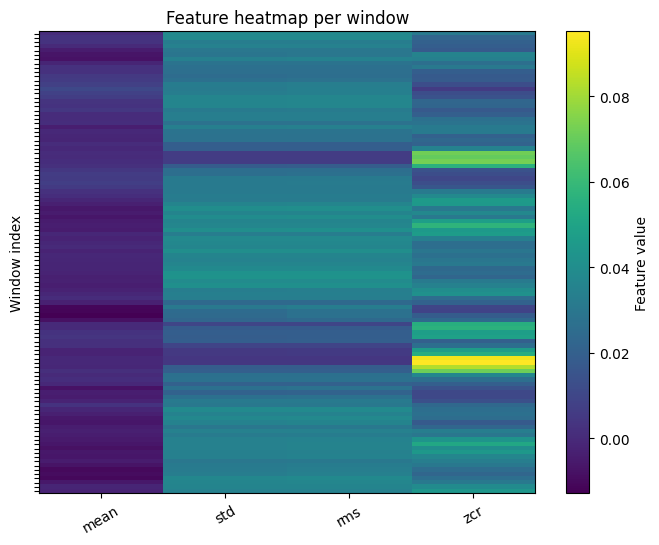

In [3]:
import numpy as np
import matplotlib.pyplot as plt
  # change this

d = np.load(npz_path)
W = d["windows"]

rms = np.sqrt(np.mean(W**2, axis=1))
mean = np.mean(W, axis=1)
std = np.std(W, axis=1)
zcr = np.mean(np.sign(W[:, 1:]) != np.sign(W[:, :-1]), axis=1)  # zero-crossing rate

F = np.stack([mean, std, rms, zcr], axis=1)  # (n_windows, 4)

plt.figure(figsize=(8, 6))
plt.imshow(F, aspect="auto", interpolation="nearest")
plt.yticks(range(F.shape[0]), [])
plt.xticks(range(4), ["mean", "std", "rms", "zcr"], rotation=30)
plt.title("Feature heatmap per window")
plt.colorbar(label="Feature value")
plt.ylabel("Window index")
plt.show()

In [5]:
raw_npz_path = Path("../../data/emglab/windows_w400_h100/N2001A01AP51.npz")
ds_npz_path  = Path("../../data/emglab/windows_w400_h100_minmax_f25/N2001A01AP51.npz")

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from ipywidgets import interact, IntSlider

raw_data = np.load(raw_npz_path, allow_pickle=False)
ds_data  = np.load(ds_npz_path, allow_pickle=False)

raw_windows = raw_data["windows"]
ds_windows  = ds_data["windows_downsampled"]
sel_idx     = ds_data["selected_indices"]

win_ms = float(raw_data["win_ms"]) if "win_ms" in raw_data else None

def show_window(window_idx=0):
    raw_w = raw_windows[window_idx]
    ds_w = ds_windows[window_idx]
    idx_w = sel_idx[window_idx]

    if win_ms is not None:
        t_raw = np.linspace(0, win_ms, len(raw_w))
        t_ds = t_raw[idx_w]
        x_label = "Time (ms)"
    else:
        t_raw = np.arange(len(raw_w))
        t_ds = idx_w
        x_label = "Sample index"

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].plot(t_raw, raw_w, marker='o', markersize=2, linewidth=1.2)
    axes[0].set_title(f"Raw window #{window_idx}")
    axes[0].set_xlabel(x_label)
    axes[0].set_ylabel("Amplitude")
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(t_ds, ds_w, marker='o', markersize=3, linewidth=1.5)
    axes[1].set_title(f"Downsampled window #{window_idx}")
    axes[1].set_xlabel(x_label)
    axes[1].set_ylabel("Amplitude")
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 4))
    plt.plot(t_raw, raw_w, color="gray", alpha=0.7, linewidth=1.0, label="Raw window")
    plt.plot(t_ds, ds_w, marker='o', linewidth=1.8, label="Downsampled window")
    plt.scatter(t_ds, ds_w, s=20, label="Kept points")
    plt.title(f"Overlay: raw vs downsampled window #{window_idx}")
    plt.xlabel(x_label)
    plt.ylabel("Amplitude")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

interact(show_window, window_idx=IntSlider(min=0, max=len(raw_windows)-1, step=1, value=0));

interactive(children=(IntSlider(value=0, description='window_idx', max=107), Output()), _dom_classes=('widget-…